# Chartbook — revenue by ESA type

The companion to [`chartbook.ipynb`](chartbook.ipynb), which explains how to
read every chart here (levels, seams, projection shading, captions). This book
holds the **revenue tree** (`ESA_REV`): the ten ESA revenue types `R01`–`R10`
that sum to `TR`, plus the Level II splits of D-S13-005 — `R02_A` excise
duties (remainder `R02_X`) and `R06_E` employers' / `R06_H` households'
actual social contributions (remainder `R06_X`, the imputed and
supplementary part). A remainder plus its Level II lines equals the parent
exactly in every year; remainders are never forecast.

| line | ESA | what it is |
|---|---|---|
| `R01` | D.211 | value added tax |
| `R02` | D.2 − D.211 | other taxes on production and imports — `R02_A` excise duties (D.214A + D.2122C) and `R02_X` the rest |
| `R03` | D.51 households | taxes on household income incl. holding gains |
| `R04` | D.51 corporations | taxes on corporate income |
| `R05` | D.51 other + D.59 + D.91 | other current taxes and capital taxes |
| `R06` | D.61 | net social contributions — `R06_E` employers' actual (D.611), `R06_H` households' actual (D.613), `R06_X` imputed and supplementary |
| `R07` | D.41 resources | interest receivable |
| `R08` | D.4 − D.41 | other property income |
| `R09` | P.11 + P.12 + P.131 | sales of goods and services |
| `R10` | D.39 + D.7 + D.92 + D.99 | other current and capital transfers receivable |
| `TR` | total | total revenue |

The revenue tree was moved out of the main book only for size: the two
books share the setup cell and the caption discipline, and "no projection
published" and its five reasons mean the same thing here.


In [1]:
import io
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image as Image_display, display
from PIL import Image

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "deliverables" / "series_catalogue.csv").exists())
DELIV = ROOT / "deliverables"
load = lambda n: pd.read_csv(DELIV / f"{n}.csv")

EXPENDITURE = load("expenditure_cofog")
ECONOMIC = load("expenditure_esa")   # the ESA_EXP tree, charted in chartbook_esa.ipynb
REVENUE = load("revenue_esa")
TREE = pd.concat([EXPENDITURE, ECONOMIC, REVENUE], ignore_index=True)
LEDGER = load("balance_ledger")
LEVELS = load("weo_levels_bridge")
RECON = load("weo_reconciliation")
CATALOGUE = load("series_catalogue")
FORECASTS = load("statistical_forecasts")
# the same forecasts in currency, for the levels charts: one nominal GDP
# path per country, our outturn anchored and chained on the WEO's NGDP
# growth. Built by `ggfiscal forecast-levels`; nothing is multiplied here.
FORECAST_LCU = load("forecast_levels").query("method == 'combination'")

LATEST = sorted(LEVELS.weo_vintage.dropna().unique())[-1]
NAME = dict(zip(CATALOGUE.iso3, CATALOGUE.country))

# Categorical slots 1-4 of the validated palette, assigned by entity and never
# reused: blue is always our strict series, orange always the maximum
# extension, aqua always the IMF WEO, and violet always a statistical
# forecast — the same violet the forecast books use for the same thing. Line
# style repeats the distinction so identity never rests on colour alone.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
VIOLET = "#4a3aa7"
INK, MUTED, AXIS = "#0b0b0b", "#898781", "#c3c2b7"
SURFACE, SHADE = "#fcfcfb", "#eceae4"

plt.rcParams.update({
    "figure.figsize": (6.9, 2.7), "figure.dpi": 72,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 9, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "grid.color": AXIS, "grid.alpha": 0.45, "grid.linewidth": 0.6,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 2,
})


# Every chart runs from its country's earliest published year to 2031, so any
# two can be laid side by side and read against the same calendar. 2031 is the
# end of the near-term forecast horizon; four series per country carry
# long-term legs to 2036 or 2070, and those run off the right edge with a
# marker saying how far they go. The values are all in the flat files.
XMAX = 2031
XLIM = {}
for _iso in TREE.iso3.unique():
    _years = pd.concat([TREE.query("iso3 == @_iso").year,
                        LEDGER.query("iso3 == @_iso").year])
    _lo = int(_years.min())
    _pad = (XMAX - _lo) * 0.035
    XLIM[_iso] = (_lo - _pad, XMAX + _pad)

# To read all three countries against one calendar instead of one per country,
# uncomment these two lines and re-run from here:
# _LO = min(lo for lo, _ in XLIM.values())
# XLIM = {iso: (_LO, XMAX + (XMAX - _LO) * 0.035) for iso in XLIM}


def _palette():
    """A fixed palette of exactly the colours these charts use.

    Quantising is what keeps this notebook renderable — at full colour depth
    its 100-odd figures came to 3.3 MB, at which size GitHub's notebook
    renderer gives up and shows "Loading" forever. But an *adaptive* palette
    allocates slots by pixel count, and a dashed line has few pixels: at 32
    colours it crushed the orange series to a muddy #927670. So the palette
    is fixed instead — each mark colour exactly, plus its blends toward the
    two backgrounds for antialiasing — and the brand hues survive whatever
    share of the canvas they happen to occupy.
    """
    from matplotlib.colors import to_rgb

    entries = [to_rgb(SURFACE), to_rgb(SHADE)]
    # VIOLET is appended last on purpose: adding a colour to the front of
    # this list would renumber every index and rewrite every figure in the
    # book for no change in what any of them shows.
    for mark in (INK, MUTED, AXIS, BLUE, ORANGE, AQUA, VIOLET):
        m = to_rgb(mark)
        for ground in (SURFACE, SHADE):
            g = to_rgb(ground)
            entries += [tuple(m[i] + (g[i] - m[i]) * t for i in range(3))
                        for t in (0.0, 0.2, 0.4, 0.6, 0.8)]
    flat = [round(255 * v) for e in entries for v in e]
    pal = Image.new("P", (1, 1))
    pal.putpalette(flat + [0] * (768 - len(flat)))
    return pal


PALETTE = _palette()


def show(fig):
    """Display a figure as a PNG quantised onto that fixed palette."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=plt.rcParams["figure.dpi"])
    plt.close(fig)
    small = Image.open(buf).convert("RGB").quantize(
        palette=PALETTE, dither=Image.Dither.NONE)
    out = io.BytesIO()
    small.save(out, format="PNG", optimize=True)
    display(Image_display(data=out.getvalue()))


def thousands(ax):
    """Levels run to seven figures; unseparated tick labels are unreadable."""
    ax.yaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))


def _seams(g):
    """Years where the source or the construction method changes."""
    g = g.sort_values("year")
    key = list(zip(g.observation_type, g.source_id.fillna("")))
    return [int(y) for (a, b), y in zip(zip(key, key[1:]), g.year[1:]) if a != b]


# Why a series carries no projection. The pipeline records one of five
# statuses per undeclared line; these are the plain-language readings.
WHY_NO_FORECAST = {
    "no_official_forecast":
        "nobody publishes a forecast of this line on a compatible concept",
    "source_blocked":
        "a forecast exists but the publication cannot be ingested",
    "grade_below_strict":
        "the only candidate covers too little of the line to enter strict",
    "no_machine_readable_source":
        "the candidate source has no ESA-complete machine-readable series",
    "not_extended":
        "a total, deliberately not given a forecast path of its own",
}


def _forecast_lines(row):
    """State, in words, how far each variant projects and why it stops."""
    actual = int(row.final_actual_year)
    out = [f"outturn:  {int(row.first_year)}-{actual}"]
    # the recorded reason is prefixed with its own [status] tag, which reads
    # oddly on a line that says the variant does project; the status is said
    # in words below anyway
    untag = lambda t: t.split("] ", 1)[1] if t.startswith("[") else t
    reason = untag(row.reason_series_ends) if isinstance(
        row.reason_series_ends, str) else ""
    note = row.forecast_note if isinstance(row.forecast_note, str) else ""
    status = row.forecast_status if isinstance(row.forecast_status, str) else ""
    headline = WHY_NO_FORECAST.get(status, "")

    def say(end):
        if end > actual:
            return f"projects to {end} — {reason or 'source horizon'}"
        why = note or reason or "no forecast source identified"
        return f"NO PROJECTION — {headline or 'see note'}. {why}"

    strict, maximum = say(int(row.final_strict_year)), say(int(row.final_maximum_year))
    if strict == maximum:                       # the common case: say it once
        out.append(f"{'both:'.ljust(9)} {strict}")
    else:
        out.append(f"{'strict:'.ljust(9)} {strict}")
        out.append(f"{'maximum:'.ljust(9)} {maximum}")
    return out


def _benchmark_caption(iso3, line_code):
    """The statistical leg, said in the same voice as the recipe above it."""
    f = FORECAST_LCU.query("iso3 == @iso3 and line_code == @line_code")
    if f.empty:
        return []
    end = f.sort_values("year").iloc[-1]
    return [f"benchmark: statistical combination of auto.arima, ets, prophet "
            f"and uc to {int(end.year)} — {end.value_lcu_mn:,.0f} "
            f"{end.currency} mn (80% {end.lo80_lcu_mn:,.0f} to "
            f"{end.hi80_lcu_mn:,.0f}), on GDP {end.gdp_basis} from "
            f"{int(end.gdp_anchor_year)}. Fitted on outturn only; a benchmark, "
            f"not a published forecast."]


def _caption(iso3, line_code):
    row = CATALOGUE.query("iso3 == @iso3 and line_code == @line_code").iloc[0]
    recipe = str(row.recipe_maximum_extension).replace(" | ", "  ·  ")
    parts = [fill(f"recipe:   {recipe}", 104, subsequent_indent=" " * 10)]
    lines = _forecast_lines(row)
    # only where the strict series carries no official projection — where one
    # exists it is the number, exactly as in the forecast panels
    if int(row.final_strict_year) <= int(row.final_actual_year):
        lines += _benchmark_caption(iso3, line_code)
    parts += [fill(line, 104, subsequent_indent=" " * 10) for line in lines]
    return "\n".join(parts)


def chart(iso3, line_code, caption=True, xlim=None):
    """One series, both variants, with its seams and projection region.

    `xlim` overrides the shared country axis to zoom in on a stretch.
    """
    g = TREE.query("iso3 == @iso3 and line_code == @line_code")
    strict = g.query("variant == 'strict'").sort_values("year")
    mx = g.query("variant == 'maximum_extension'").sort_values("year")
    label = g.line_label.iloc[0]
    actual = g.query("basis == 'actual'").year.max()
    furthest = int(mx.year.max())

    fig, ax = plt.subplots()
    # The projection region is shaded on every chart, whether or not the
    # series reaches into it: a line that stops at the shading edge is one
    # nobody publishes a forecast for, and that should look different from a
    # line that carries on.
    lo, hi = xlim or XLIM[iso3]
    ax.set_xlim(lo, hi)
    ax.axvspan(actual, hi, color=SHADE, zorder=0, lw=0)
    # Plot only what the window shows, plus one point past the edge so the
    # line reaches it. Without this the y-axis would autoscale to values that
    # are not on the chart, flattening everything that is.
    window = lambda d: d[d.year <= hi + 1]
    if len(mx) > len(strict):
        ax.plot(window(mx).year, window(mx).value_lcu_mn, color=ORANGE,
                ls="--", label="maximum_extension")
    ax.plot(window(strict).year, window(strict).value_lcu_mn, color=BLUE,
            label="strict")
    # The statistical benchmark, in currency, where nobody publishes a
    # forecast of this line. Where an official projection exists it is the
    # number and this is not drawn — the same rule as the forecast panels.
    # 80% only: the 95% band swamps a levels axis, and it is in the forecast
    # books where it belongs.
    bench = FORECAST_LCU.query("iso3 == @iso3 and line_code == @line_code and "
                               "year <= @hi").sort_values("year")
    # Keyed on STRICT, and anchored on strict's own last outturn — not on
    # `actual`, which comes from both variants and can be a year later where
    # maximum_extension carries a stitched 2025 the strict series does not.
    # A maximum_extension proxy leg is not an official forecast, so a line
    # that has one still gets the benchmark. Same test the caption uses.
    strict_actual = strict[strict.basis == "actual"]
    drew_benchmark = (int(strict.year.max()) <= actual and len(bench)
                      and len(strict_actual))
    if drew_benchmark:
        anchor_year = int(strict_actual.year.max())
        anchor = float(strict_actual.value_lcu_mn.iloc[-1])
        years = [anchor_year, *bench.year]
        ax.fill_between(years, [anchor, *bench.lo80_lcu_mn],
                        [anchor, *bench.hi80_lcu_mn], color=VIOLET,
                        alpha=0.18, lw=0, zorder=1, label="benchmark 80%")
        ax.plot(years, [anchor, *bench.value_lcu_mn], color=VIOLET, ls="--",
                zorder=4, label="statistical benchmark")
    for year in _seams(mx):
        ax.axvline(year, color=MUTED, ls=":", lw=0.9, alpha=0.8, zorder=1)
    if furthest <= actual and not drew_benchmark:
        ax.annotate("no projection published", (actual, 0.94),
                    xycoords=("data", "axes fraction"),
                    xytext=(4, 0), textcoords="offset points",
                    color=MUTED, fontsize=7.5, va="top")
    elif furthest > hi:
        ax.annotate(f"continues to {furthest} →", (hi, 0.94),
                    xycoords=("data", "axes fraction"),
                    xytext=(-4, 0), textcoords="offset points",
                    color=MUTED, fontsize=7.5, va="top", ha="right")

    ax.set_title(f"{NAME[iso3]} · {line_code} — {label}")
    ax.set_ylabel(f"{g.currency.iloc[0]} mn")
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    thousands(ax)
    if len(mx) > len(strict) or drew_benchmark:
        ax.legend(loc="upper left", ncol=2 if drew_benchmark else 1)
    fig.tight_layout()
    show(fig)
    if caption:
        print(_caption(iso3, line_code))


def ledger_chart(iso3, quantity, xlim=None):
    """One balance-ledger quantity. Outturn only; the variants are identical."""
    g = LEDGER.query("iso3 == @iso3 and variant == 'strict'").sort_values("year")
    col = f"{quantity.lower()}_lcu_mn"
    meaning = {"TR": "total revenue (balance anchor's own total)",
               "TE": "total expenditure (balance anchor's own total)",
               "NLB": "net lending (+) / net borrowing (-) = TR - TE",
               "NI": "net interest = GF01_7 - R07",
               "PB": "primary balance = NLB + NI"}[quantity]

    actual = int(g.year.max())
    fig, ax = plt.subplots()
    lo, hi = xlim or XLIM[iso3]
    ax.set_xlim(lo, hi)
    ax.axvspan(actual, hi, color=SHADE, zorder=0, lw=0)
    ax.plot(g.year, g[col], color=BLUE)
    if (g[col] < 0).any():
        ax.axhline(0, color=AXIS, lw=1, zorder=0)
    ax.annotate("no projection published", (actual, 0.94),
                xycoords=("data", "axes fraction"),
                xytext=(4, 0), textcoords="offset points",
                color=MUTED, fontsize=7.5, va="top")
    ax.set_title(f"{NAME[iso3]} · ledger {quantity} — {meaning}")
    ax.set_ylabel(f"{g.currency.iloc[0]} mn")
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    thousands(ax)
    fig.tight_layout()
    show(fig)
    missing = g[g[col].isna()].year.tolist()
    print(f"outturn:  {int(g.year.min())}-{actual}, source {g.source_id.iloc[0]}"
          + (f"; no value for {missing}" if missing else ""))
    print(fill("forecast: NO PROJECTION — the ledger is outturn-only by "
               "design. Building it forward would mean summing lines whose "
               "forecast coverage is partial, which would misstate the "
               "totals; the forecast-side comparison lives in section 4 "
               "instead, where the coverage gap is explicit.", 104,
               subsequent_indent=" " * 10))


WEO_Q = {
    "revenue": ("tr_ours_mn", "tr_weo_mn", "gap_tr_pct_te",
                "total revenue", "WEO GGR"),
    "expenditure": ("te_ours_mn", "te_weo_mn", "gap_te_pct_te",
                    "total expenditure", "WEO GGX"),
    "nlb": ("nlb_ours_mn", "nlb_weo_mn", "gap_nlb_pct_te",
            "net lending / borrowing", "WEO GGXCNL"),
}


def weo_chart(iso3, quantity, vintage=None):
    """Ours against the IMF WEO, level and gap, over the overlap years."""
    vintage = vintage or LATEST
    ours_col, weo_col, gap_col, label, weo_label = WEO_Q[quantity]
    g = (LEVELS.query("block == 'history' and iso3 == @iso3 and "
                      "weo_vintage == @vintage").sort_values("year"))
    currency = LEDGER.query("iso3 == @iso3").currency.iloc[0]

    fig, (ax, gx) = plt.subplots(2, 1, figsize=(6.6, 3.8), sharex=True,
                                 height_ratios=[2.6, 1])
    ax.plot(g.year, g[ours_col], color=BLUE, label="ours")
    ax.plot(g.year, g[weo_col], color=AQUA, ls="--", label=weo_label)
    if (g[ours_col] < 0).any():
        ax.axhline(0, color=AXIS, lw=1, zorder=0)

    # Same country axis as sections 1-3, so this chart can be read against
    # them. The comparison itself ends at the last outturn, because our
    # ledger does; the years after it are the shaded projection region with
    # nothing on our side to put in it.
    ax.set_xlim(*XLIM[iso3])
    ax.axvspan(g.year.max(), XLIM[iso3][1], color=SHADE, zorder=0, lw=0)
    ax.annotate("no projection published", (g.year.max(), 0.04),
                xycoords=("data", "axes fraction"),
                xytext=(4, 0), textcoords="offset points",
                color=MUTED, fontsize=7.5, va="bottom")

    # Direct labels: the aqua step sits below 3:1 on this surface, so identity
    # is carried by text on the mark as well as by the legend. The two series
    # nearly coincide by construction, so the labels are staggered off each
    # other rather than drawn on top of one another.
    ends = [(ours_col, BLUE, "ours"), (weo_col, AQUA, weo_label)]
    lo, hi = ax.get_ylim()
    close = abs(g[ours_col].iloc[-1] - g[weo_col].iloc[-1]) < (hi - lo) * 0.06
    for (col, colour, text), dy in zip(ends, (9, -9) if close else (0, 0)):
        y = g[col].iloc[-1]
        # keep the label inside the axes: near the top it would otherwise ride
        # up into the title
        if (y - lo) / (hi - lo) > 0.86:
            dy -= 16
        ax.annotate(text, (g.year.iloc[-1], y),
                    xytext=(6, dy), textcoords="offset points",
                    color=colour, fontsize=8.5, va="center")
    ax.set_title(f"{NAME[iso3]} · {label} — ours vs IMF WEO")
    ax.set_ylabel(f"{currency} mn")
    ax.grid(axis="y")
    thousands(ax)
    ax.legend(loc="upper left")

    gx.plot(g.year, g[gap_col], color=BLUE)
    gx.axhline(0, color=AXIS, lw=1, zorder=0)
    gx.set_ylabel("gap, % of TE")
    gx.grid(axis="y")
    gx.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    fig.tight_layout()
    show(fig)

    gap = g[gap_col]
    kinds = ", ".join(sorted(g.gap_classification.dropna().unique()))
    print(f"WEO vintage {vintage}; overlap {int(g.year.min())}-"
          f"{int(g.year.max())}; gap mean {gap.mean():+.3f}% of TE, "
          f"sigma {gap.std():.3f}, range {gap.min():+.3f} to "
          f"{gap.max():+.3f}; classified: {kinds}")


print(f"loaded {len(TREE):,} tree rows, {len(LEDGER)} ledger rows, "
      f"{len(LEVELS)} bridge rows, {len(FORECASTS):,} statistical "
      f"forecast rows ({len(FORECAST_LCU):,} of them also in currency); "
      f"WEO vintages "
      f"{', '.join(sorted(LEVELS.weo_vintage.dropna().unique()))}; "
      f"latest {LATEST}")

loaded 10,544 tree rows, 196 ledger rows, 398 bridge rows, 3,610 statistical forecast rows (722 of them also in currency); WEO vintages 2025-04, 2025-10, 2026-04; latest 2026-04


## 1. United Kingdom — revenue by ESA type

Ten revenue types and their total, with the excise-duty and contributions splits beside their parents.

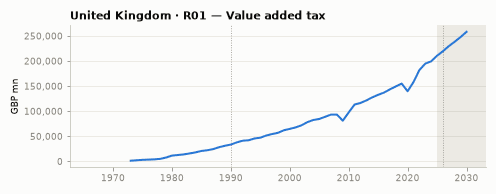

recipe:   1973-1989: backward stitch (OECD_RS, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2030: composite forecast (OBR_EFO_LATEST, grade B)
outturn:  1973-2025
both:     projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [2]:
chart("GBR", "R01")

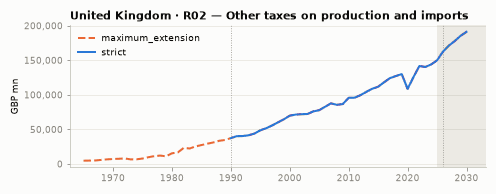

recipe:   1965-1989: backward stitch (OECD_RS, grade C)  ·  1990-2025: derived by identity
          (ONS_GG_RECEIPTS, grade A)  ·  2026-2030: composite forecast (OBR_EFO_LATEST, grade B)
outturn:  1965-2025
both:     projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [3]:
chart("GBR", "R02")

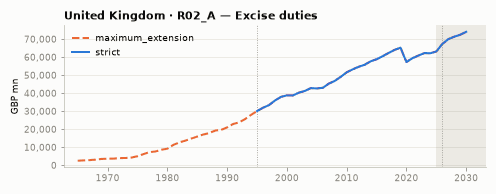

recipe:   1965-1994: backward stitch (OECD_RS, grade C)  ·  1995-2025: anchor outturn (ONS_TAX_DETAIL,
          grade A)  ·  2026-2030: composite forecast (OBR_EFO_LATEST, grade B)
outturn:  1965-2025
both:     projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [4]:
chart("GBR", "R02_A")

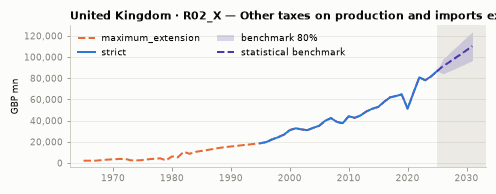

recipe:   1965-1989: derived by identity (ONS_GG_RECEIPTS, grade C)  ·  1995-2025: derived by identity
          (ONS_GG_RECEIPTS, grade A)
outturn:  1965-2025
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D-S13-005): the remainder R02 - R02_A is derived only
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 110,248 GBP mn (80%
          96,710 to 123,786), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [5]:
chart("GBR", "R02_X")

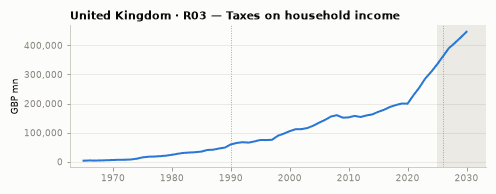

recipe:   1965-1989: backward stitch (OECD_RS, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2030: composite forecast (OBR_EFO_LATEST, grade B)
outturn:  1965-2025
both:     projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [6]:
chart("GBR", "R03")

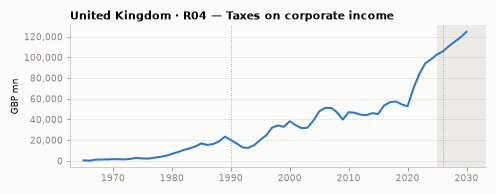

recipe:   1965-1989: backward stitch (OECD_RS, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2030: composite forecast (OBR_EFO_LATEST, grade B)
outturn:  1965-2025
both:     projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [7]:
chart("GBR", "R04")

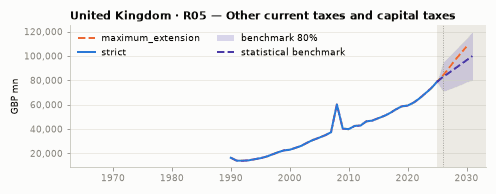

recipe:   1990-2025: derived by identity (ONS_GG_RECEIPTS, grade A)  ·  2026-2030: composite forecast
          (OBR_EFO_LATEST, grade C)
outturn:  1990-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. OBR council
          tax + inheritance tax + licence fee composite measured at 79% of the line (C) — applied in
          maximum_extension to 2030; the remaining D.59/D.91 items have no forecast anywhere (D7 lists
          R05 as partial); AMECO UTKG (11%, D) recorded, not applied
maximum:  projects to 2030 — OBR council tax + inheritance tax + licence fee composite measured at 79%
          of the line (C) — applied in maximum_extension to 2030; the remaining D.59/D.91 items have no
          forecast anywhere (D7 lists R05 as partial); AMECO UTKG (11%, D) recorded, not applied
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 99,962 GBP mn (80%
          80,121 to 119,803), on GDP anchored_outturn_chained_

In [8]:
chart("GBR", "R05")

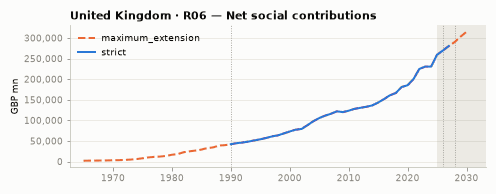

recipe:   1965-1989: backward stitch (OECD_RS, grade C)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)  ·  2028-2030: official forecast
          (OBR_EFO_LATEST, grade C)
outturn:  1965-2025
strict:   projects to 2027 — source horizon: OBR_EFO_LATEST ends 2030 (V10)
maximum:  projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [9]:
chart("GBR", "R06")

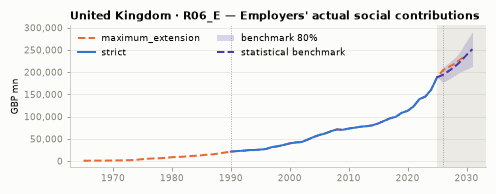

recipe:   1965-1989: backward stitch (OECD_RS, grade C)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2030: official forecast (OBR_EFO_LATEST, grade C)
outturn:  1965-2025
strict:   NO PROJECTION — see note. source horizon: OBR_EFO_LATEST ends 2030 (V10)
maximum:  projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 251,766 GBP mn (80%
          212,835 to 290,696), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [10]:
chart("GBR", "R06_E")

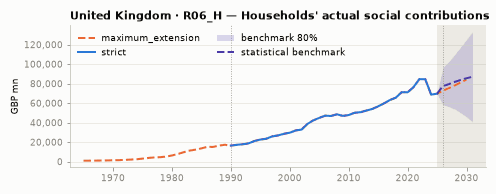

recipe:   1965-1989: backward stitch (OECD_RS, grade C)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2030: composite forecast (OBR_EFO_LATEST, grade C)
outturn:  1965-2025
strict:   NO PROJECTION — see note. source horizon: OBR_EFO_LATEST ends 2030 (V10)
maximum:  projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 87,012 GBP mn (80%
          40,897 to 133,127), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [11]:
chart("GBR", "R06_H")

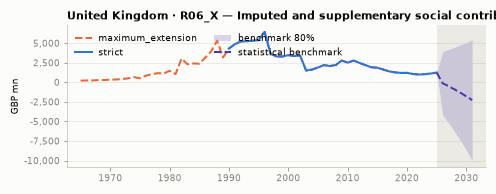

recipe:   1965-1989: derived by identity (ONS_GG_RECEIPTS, grade C)  ·  1990-2025: derived by identity
          (ONS_GG_RECEIPTS, grade A)
outturn:  1965-2025
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D-S13-005): the remainder R06 - R06_E - R06_H (imputed and
          supplementary contributions) is derived only
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — -2,281 GBP mn (80%
          -10,022 to 5,459), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [12]:
chart("GBR", "R06_X")

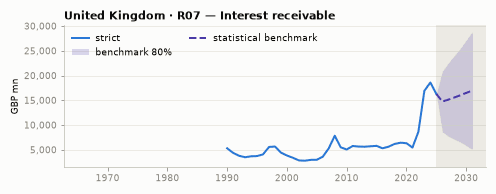

recipe:   1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
both:     NO PROJECTION — the candidate source has no ESA-complete machine-readable series. no usable GG
          interest-receivable forecast: AMECO has no D.41 resources series (UYVG is subsidies); DSM
          publishes payable interest only; the OBR 'PS interest and dividend receipts' candidate
          (D-S7-003) mixes dividends and the PS perimeter into the line and measures outside every band
          — recorded, not applied; NI/PB forecast ledger therefore stays empty (§4.3)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 16,965 GBP mn (80% 5,097
          to 28,832), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn only; a
          benchmark, not a published forecast.


In [13]:
chart("GBR", "R07")

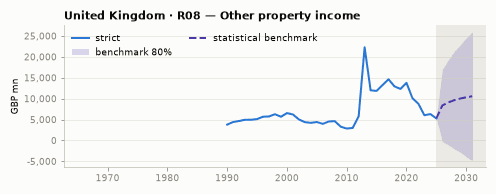

recipe:   1990-2025: derived by identity (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 10,577 GBP mn (80%
          -4,837 to 25,992), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [14]:
chart("GBR", "R08")

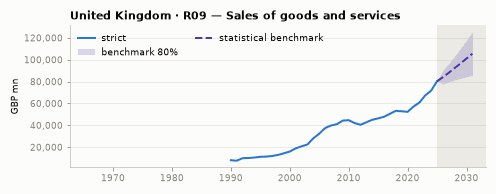

recipe:   1990-2025: derived by identity (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
both:     NO PROJECTION — the candidate source has no ESA-complete machine-readable series. AMECO
          publishes no UK UTOG/UROG history (OQ-4 pattern) and the EFO receipts tables do not separate
          P.11+P.12+P.131 sales (GOS and 'other receipts' are different concepts) — no measurable
          composite
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 105,581 GBP mn (80%
          85,651 to 125,511), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [15]:
chart("GBR", "R09")

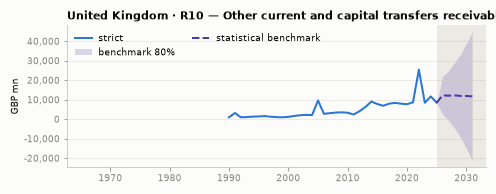

recipe:   1990-2025: derived by identity (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 11,756 GBP mn (80%
          -21,294 to 44,805), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [16]:
chart("GBR", "R10")

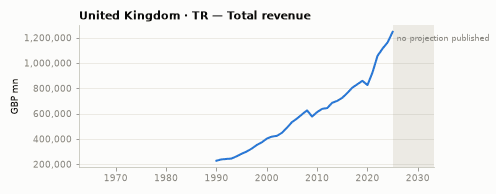

recipe:   1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
both:     NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): used in V15 only


In [17]:
chart("GBR", "TR")

## 2. France — revenue by ESA type

Ten revenue types and their total, with the excise-duty and contributions splits beside their parents.

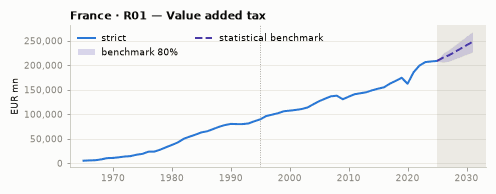

recipe:   1965-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1965-2025
both:     NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPFP_PSTAB (prélèvements obligatoires) is PDF-only; §11.4 manual ingestion requires an
          independent second keying unavailable to a single-agent session (OQ-5 precedent) — OQ-6;
          strict ends at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 247,491 EUR mn (80%
          226,869 to 268,114), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [18]:
chart("FRA", "R01")

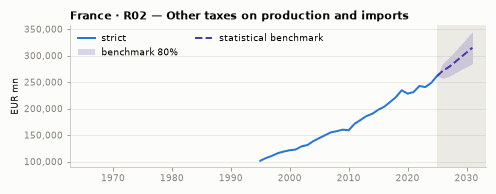

recipe:   1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
both:     NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPFP_PSTAB is PDF-only; §11.4 manual ingestion requires an independent second keying
          unavailable to a single-agent session (OQ-5 precedent) — OQ-6; strict ends at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 314,885 EUR mn (80%
          284,916 to 344,853), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [19]:
chart("FRA", "R02")

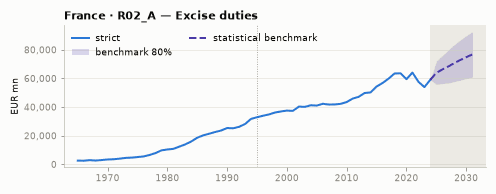

recipe:   1965-1994: backward stitch (OECD_RS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_TAXAG, grade A)
outturn:  1965-2024
both:     NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPFP_PSTAB (excise duties are in the prélèvements obligatoires tables) is PDF-only; §11.4
          manual ingestion requires an independent second keying unavailable to a single-agent session
          (OQ-5 precedent) — OQ-6; strict ends at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 76,724 EUR mn (80%
          60,898 to 92,550), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [20]:
chart("FRA", "R02_A")

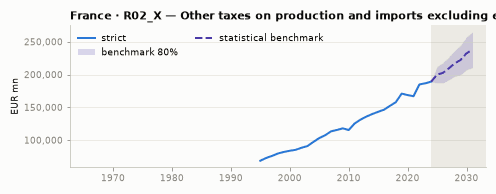

recipe:   1995-2024: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D-S13-005): the remainder R02 - R02_A is derived only
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 237,819 EUR mn (80%
          210,503 to 265,134), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [21]:
chart("FRA", "R02_X")

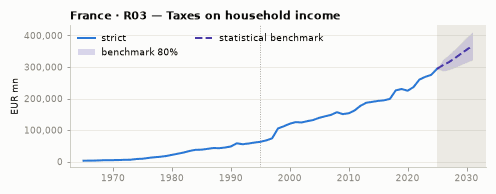

recipe:   1965-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1965-2025
both:     NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPFP_PSTAB is PDF-only; §11.4 manual ingestion requires an independent second keying
          unavailable to a single-agent session (OQ-5 precedent) — OQ-6; strict ends at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 367,086 EUR mn (80%
          322,670 to 411,503), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [22]:
chart("FRA", "R03")

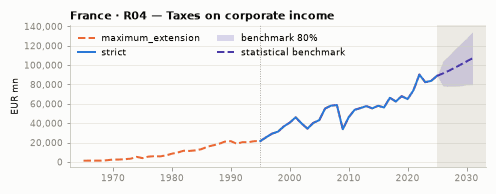

recipe:   1965-1994: backward stitch (OECD_RS, grade C)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1965-2025
both:     NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPFP_PSTAB is PDF-only; §11.4 manual ingestion requires an independent second keying
          unavailable to a single-agent session (OQ-5 precedent) — OQ-6; strict ends at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 107,079 EUR mn (80%
          79,796 to 134,362), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [23]:
chart("FRA", "R04")

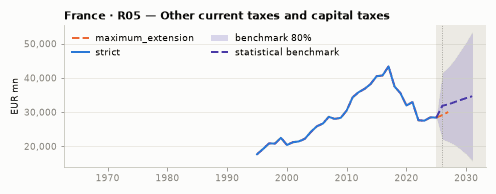

recipe:   1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: proxy forecast
          (EC_AMECO, grade C)
outturn:  1995-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UTKG
          covers 76% of the line (grade C) — no strict forecast; applied in maximum_extension as a §7.8
          single-component proxy to 2027; D7 lists R05 as partial
maximum:  projects to 2027 — AMECO UTKG covers 76% of the line (grade C) — no strict forecast; applied
          in maximum_extension as a §7.8 single-component proxy to 2027; D7 lists R05 as partial
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 34,634 EUR mn (80%
          15,808 to 53,459), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [24]:
chart("FRA", "R05")

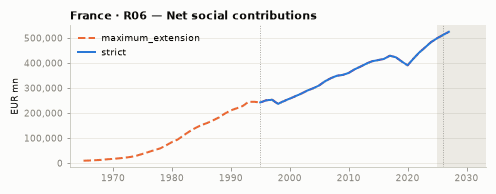

recipe:   1965-1994: backward stitch (OECD_RS, grade C)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1965-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [25]:
chart("FRA", "R06")

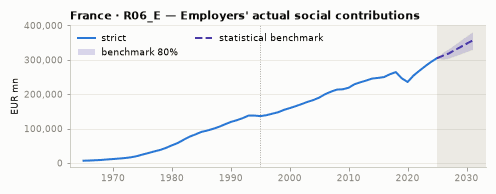

recipe:   1965-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1965-2025
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. no official
          forecast of employers' contributions separately: AMECO carries actual contributions in total
          (UTAG) and imputed (UTIG) but no employer/household split; the Steuerschätzung does not cover
          contributions; BMAS is GRV-only and PDF (OQ-5); strict and maximum end at the last actual
          (D-S13-005)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 355,823 EUR mn (80%
          330,282 to 381,363), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [26]:
chart("FRA", "R06_E")

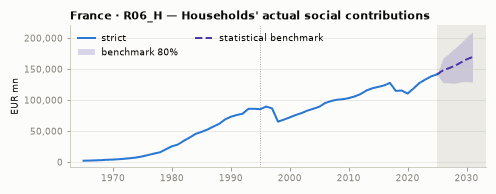

recipe:   1965-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1965-2025
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. as R06_E: no
          employer/household split in any reachable official forecast (D-S13-005)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 169,492 EUR mn (80%
          128,901 to 210,083), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [27]:
chart("FRA", "R06_H")

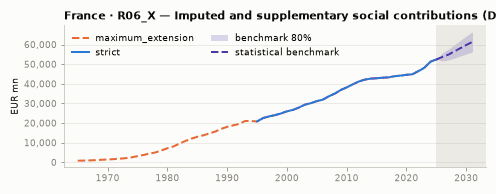

recipe:   1965-1994: derived by identity (EUROSTAT_GOV10A_MAIN, grade C)  ·  1995-2025: derived by
          identity (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1965-2025
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D-S13-005): the remainder R06 - R06_E - R06_H (imputed and
          supplementary contributions) is derived only
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 61,337 EUR mn (80%
          56,191 to 66,484), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [28]:
chart("FRA", "R06_X")

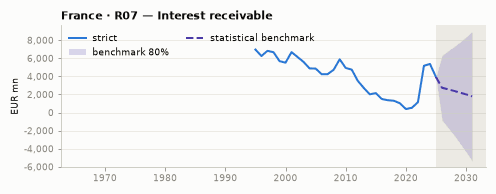

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
both:     NO PROJECTION — the candidate source has no ESA-complete machine-readable series. no usable GG
          interest-receivable forecast: AMECO has no D.41 resources series (UYVG is subsidies); DSM
          publishes payable interest only; the OBR 'PS interest and dividend receipts' candidate
          (D-S7-003) mixes dividends and the PS perimeter into the line and measures outside every band
          — recorded, not applied; NI/PB forecast ledger therefore stays empty (§4.3)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 1,802 EUR mn (80% -5,325
          to 8,929), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn only; a
          benchmark, not a published forecast.


In [29]:
chart("FRA", "R07")

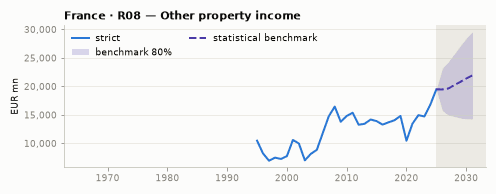

recipe:   1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 21,936 EUR mn (80%
          14,287 to 29,584), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [30]:
chart("FRA", "R08")

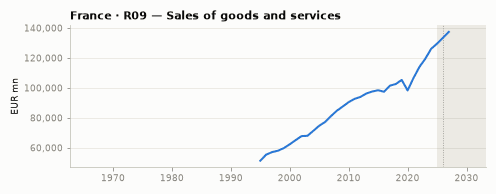

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: composite forecast
          (EC_AMECO, grade B)
outturn:  1995-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [31]:
chart("FRA", "R09")

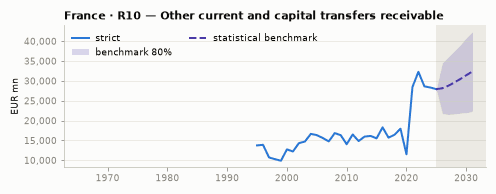

recipe:   1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 32,344 EUR mn (80%
          22,329 to 42,360), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [32]:
chart("FRA", "R10")

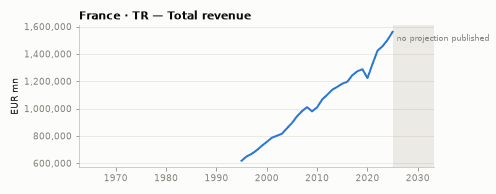

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
both:     NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): used in V15 only


In [33]:
chart("FRA", "TR")

## 3. Germany — revenue by ESA type

Ten revenue types and their total, with the excise-duty and contributions splits beside their parents.

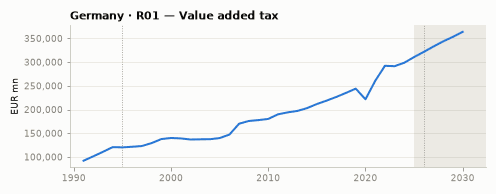

recipe:   1991-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2030: official forecast (DEU_STEUERSCHAETZUNG, grade
          B)
outturn:  1991-2025
both:     projects to 2030 — source horizon: DEU_STEUERSCHAETZUNG ends 2030 (V10)


In [34]:
chart("DEU", "R01")

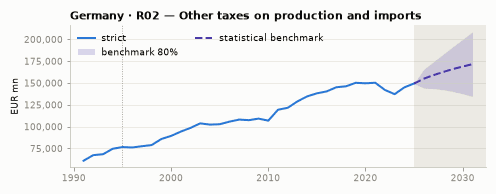

recipe:   1991-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: derived by identity
          (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1991-2025
both:     NO PROJECTION — the candidate source has no ESA-complete machine-readable series.
          Steuerschätzung publishes Länder-/Gemeindesteuern only as cash aggregates mixing D.2, D.59 and
          D.91 — no ESA-complete component set for D.2 minus D.211; AMECO UTVG is total D.2 only
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 171,609 EUR mn (80%
          134,533 to 208,685), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [35]:
chart("DEU", "R02")

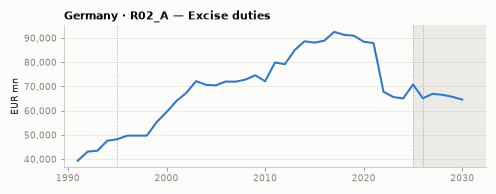

recipe:   1991-1994: backward stitch (OECD_RS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_TAXAG, grade A)  ·  2025: forward stitch (DEU_STEUERSCHAETZUNG, grade B)  ·
          2026-2030: composite forecast (DEU_STEUERSCHAETZUNG, grade B)
outturn:  1991-2025
both:     projects to 2030 — source horizon: DEU_STEUERSCHAETZUNG ends 2030 (V10)


In [36]:
chart("DEU", "R02_A")

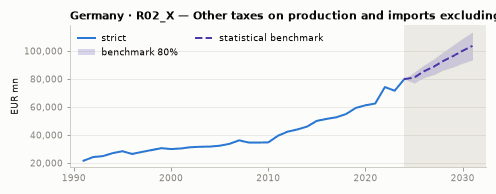

recipe:   1991-1994: derived by identity (EUROSTAT_GOV10A_MAIN, grade B)  ·  1995-2024: derived by
          identity (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1991-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D-S13-005): the remainder R02 - R02_A is derived only
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 103,612 EUR mn (80%
          93,581 to 113,642), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [37]:
chart("DEU", "R02_X")

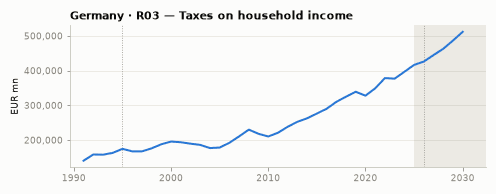

recipe:   1991-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2030: composite forecast (DEU_STEUERSCHAETZUNG, grade
          B)
outturn:  1991-2025
both:     projects to 2030 — source horizon: DEU_STEUERSCHAETZUNG ends 2030 (V10)


In [38]:
chart("DEU", "R03")

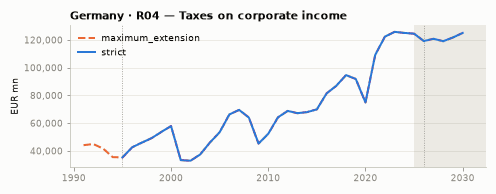

recipe:   1991-1994: backward stitch (OECD_RS, grade C)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2030: composite forecast (DEU_STEUERSCHAETZUNG, grade
          B)
outturn:  1991-2025
both:     projects to 2030 — source horizon: DEU_STEUERSCHAETZUNG ends 2030 (V10)


In [39]:
chart("DEU", "R04")

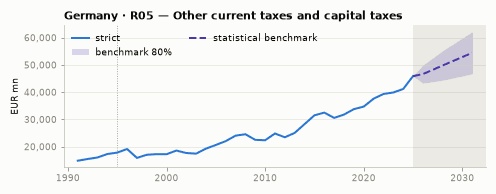

recipe:   1991-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: derived by identity
          (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1991-2025
both:     NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UTKG
          covers 34% of the line (D, not applied); Erbschaftsteuer is not separately published in the
          Steuerschätzung tables; D7 lists R05 as partial
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 54,442 EUR mn (80%
          46,747 to 62,138), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [40]:
chart("DEU", "R05")

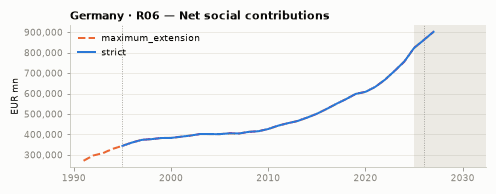

recipe:   1991-1994: backward stitch (OECD_RS, grade C)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1991-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [41]:
chart("DEU", "R06")

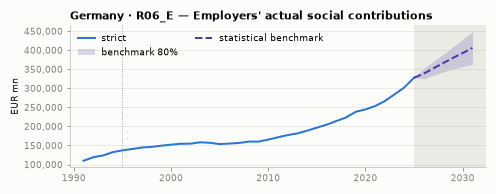

recipe:   1991-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1991-2025
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. no official
          forecast of employers' contributions separately: AMECO carries actual contributions in total
          (UTAG) and imputed (UTIG) but no employer/household split; the Steuerschätzung does not cover
          contributions; BMAS is GRV-only and PDF (OQ-5); strict and maximum end at the last actual
          (D-S13-005)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 405,757 EUR mn (80%
          363,320 to 448,195), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [42]:
chart("DEU", "R06_E")

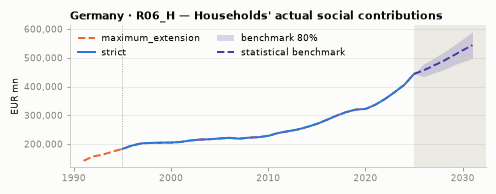

recipe:   1991-1994: backward stitch (OECD_RS, grade C)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1991-2025
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. as R06_E: no
          employer/household split in any reachable official forecast (D-S13-005)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 544,082 EUR mn (80%
          497,974 to 590,190), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [43]:
chart("DEU", "R06_H")

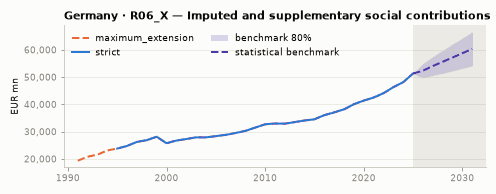

recipe:   1991-1994: derived by identity (EUROSTAT_GOV10A_MAIN, grade C)  ·  1995-2025: derived by
          identity (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1991-2025
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D-S13-005): the remainder R06 - R06_E - R06_H (imputed and
          supplementary contributions) is derived only
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 60,355 EUR mn (80%
          54,102 to 66,607), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [44]:
chart("DEU", "R06_X")

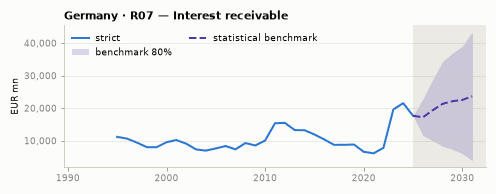

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
both:     NO PROJECTION — the candidate source has no ESA-complete machine-readable series. no usable GG
          interest-receivable forecast: AMECO has no D.41 resources series (UYVG is subsidies); DSM
          publishes payable interest only; the OBR 'PS interest and dividend receipts' candidate
          (D-S7-003) mixes dividends and the PS perimeter into the line and measures outside every band
          — recorded, not applied; NI/PB forecast ledger therefore stays empty (§4.3)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 23,660 EUR mn (80% 3,864
          to 43,456), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn only; a
          benchmark, not a published forecast.


In [45]:
chart("DEU", "R07")

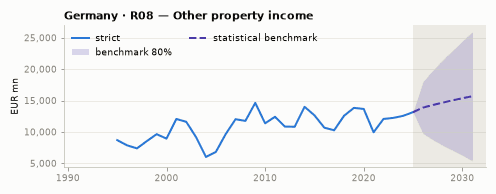

recipe:   1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 15,675 EUR mn (80% 5,412
          to 25,937), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn only; a
          benchmark, not a published forecast.


In [46]:
chart("DEU", "R08")

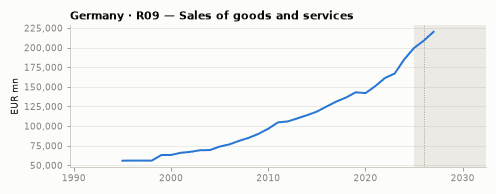

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: composite forecast
          (EC_AMECO, grade B)
outturn:  1995-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [47]:
chart("DEU", "R09")

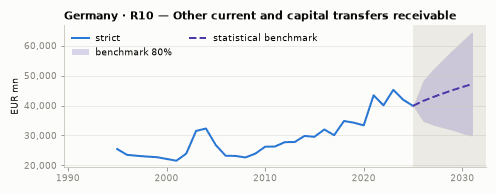

recipe:   1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 47,167 EUR mn (80%
          29,755 to 64,579), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [48]:
chart("DEU", "R10")

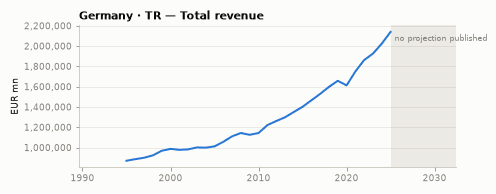

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
both:     NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): used in V15 only


In [49]:
chart("DEU", "TR")

---

## Seams in the revenue tree

The same triage table as the main book's §6, restricted to the revenue lines.

In [50]:
rows = []
for (iso3, line), g in REVENUE.query("variant == 'maximum_extension'").groupby(
        ["iso3", "line_code"]):
    for year in _seams(g):
        prev = g.query("year == @year - 1").iloc[0]
        curr = g.query("year == @year").iloc[0]
        rows.append({"iso3": iso3, "line": line, "seam_year": year,
                     "from": f"{prev.observation_type} ({prev.source_id})",
                     "to": f"{curr.observation_type} ({curr.source_id})",
                     "step_pct": round(100 * (curr.value_lcu_mn
                                              / prev.value_lcu_mn - 1), 2)})
seams = pd.DataFrame(rows).sort_values(["iso3", "line", "seam_year"])
print(f"{len(seams)} seams across {seams.groupby(['iso3', 'line']).ngroups} series")
seams.reindex(seams.step_pct.abs().sort_values(ascending=False).index).reset_index(drop=True)

44 seams across 28 series


,iso3,line,seam_year,from,to,step_pct
0,GBR,R03,1990,stitched_actual (OECD_RS),anchor_actual (ONS_GG_RECEIPTS),22.57
1,GBR,R04,1990,stitched_actual (OECD_RS),anchor_actual (ONS_GG_RECEIPTS),-14.35
2,GBR,R06_E,1990,stitched_actual (OECD_RS),anchor_actual (ONS_GG_RECEIPTS),10.14
3,DEU,R02_A,2025,anchor_actual (EUROSTAT_GOV10A_TAXAG),stitched_actual (DEU_STEUERSCHAETZUNG),8.83
4,GBR,R06_E,2026,anchor_actual (ONS_GG_RECEIPTS),direct_forecast (OBR_EFO_LATEST),8.50
5,GBR,R02,2026,derived_actual (ONS_GG_RECEIPTS),composite_forecast (OBR_EFO_LATEST),8.38
6,GBR,R03,2026,anchor_actual (ONS_GG_RECEIPTS),composite_forecast (OBR_EFO_LATEST),8.32
7,GBR,R02,1990,stitched_actual (OECD_RS),derived_actual (ONS_GG_RECEIPTS),8.05
8,DEU,R02_A,2026,stitched_actual (DEU_STEUERSCHAETZUNG),composite_forecast (DEU_STEUERSCHAETZUNG),-8.00
9,GBR,R01,1990,stitched_actual (OECD_RS),anchor_actual (ONS_GG_RECEIPTS),7.56
